## 1. Core Concepts of Machine Learning

*   **Supervised Learning:** Learning from labeled data. We have input features (X) and a known output target (y). The goal is to learn a mapping function `y = f(X)`.
    *   **Regression:** Predicting a continuous value (e.g., price, temperature, salary).
    *   **Classification:** Predicting a discrete category (e.g., Spam/Not Spam, Cat/Dog).
*   **Unsupervised Learning:** Learning from unlabeled data. The goal is to find hidden patterns or structures in the data (e.g., clustering customers into groups).

   
*   **Reinforcement Learning: Learning by interacting with an environment. An agent learns to take actions that maximize a reward over time.
    * The agent gets feedback in the form of rewards or penalties.
    * Common in robotics, games (e.g., AlphaGo), and self-driving cars.


*   **The ML Workflow:**
    1.  Get Data
    2.  Explore & Preprocess Data (EDA)
    3.  Split Data (Train/Test)
    4.  Choose & Train a Model
    5.  Evaluate the Model

## 2. Linear Regression

Linear Regression is the "hello world" of supervised learning. It assumes a linear relationship between the input features (X)
and the output target (y).

**Formula:** `y = w_1*x_1 + w_2*x_2 + ... + w_n*x_n + b`

*   `y`: The predicted value.
*   `x_i`: The input features.
*   `w_i`: The weights or coefficients (what the model learns). Represents the importance of each feature.
*   `b`: The bias or intercept.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the Data
data = {
    'YearsExperience': [1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7, 3.9, 4.0, 4.0, 4.1, 4.5, 4.9, 5.1, 5.3, 5.9, 6.0, 6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5],
    'Salary': [39343, 46205, 37731, 43525, 39891, 56642, 60150, 54445, 64445, 57189, 63218, 55794, 56957, 57081, 61111, 67938, 66029, 83088, 81363, 93940, 91738, 98273, 101302, 113812, 109431, 105582, 116969, 112635, 122391, 121872]
}
df = pd.DataFrame(data)

# 2. Exploratory Data Analysis (EDA)

print(df.head())

df.info()

   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


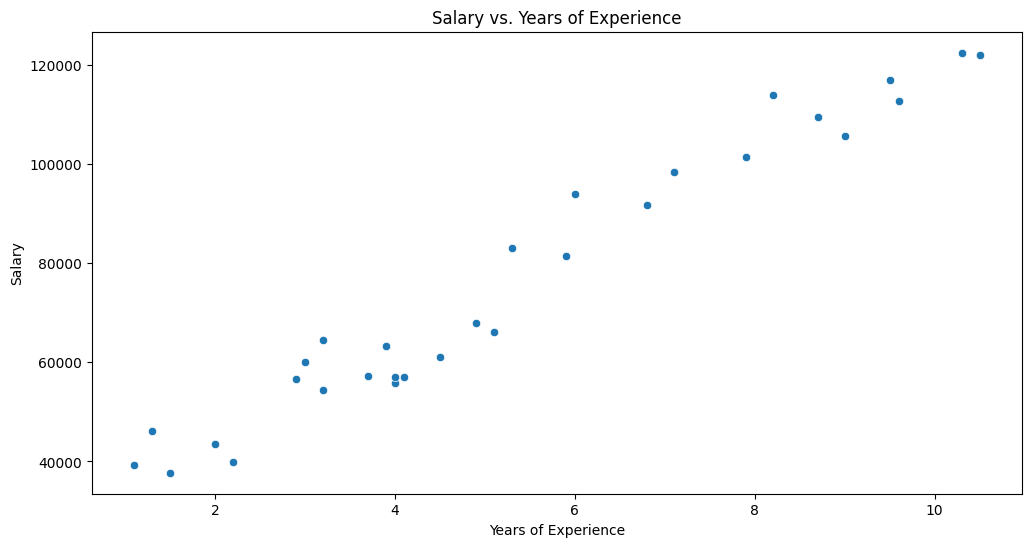

In [2]:
# Visualize the relationship
plt.figure(figsize=(12, 6))
sns.scatterplot(x='YearsExperience', y='Salary', data=df)
plt.title('Salary vs. Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

In [3]:
# 3. Prepare Data for Modeling
# X should be a 2D array, so we use [['YearsExperience']]
X = df[['YearsExperience']] #features, yesma multiple ni rakhna milxa
print(X.shape)
y = df['Salary'] #target, k herna lako

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

(30, 1)

Training set shape: (24, 1)
Testing set shape: (6, 1)


In [4]:
X_test

,YearsExperience
27,9.6
15,4.9
23,8.2
17,5.3
8,3.2
9,3.7


In [5]:
y_test

27    112635
15     67938
23    113812
17     83088
8      64445
9      57189
Name: Salary, dtype: int64

In [6]:
# 4. Choose & Train the Model
model = LinearRegression()
model.fit(X_train, y_train)
print("\nModel training complete.")

# Print the learned parameters
print(f"Coefficient (w1): {model.coef_[0]}") #aaile euta matra vayera index garya, sab nikalne vaye index nahale ni hunxa
print(f"Intercept (b): {model.intercept_}")


Model training complete.
Coefficient (w1): 9423.815323030976
Intercept (b): 25321.583011776813


O aauda min salary 25k hunuparxa vanera vanxa b le, ani coeff le chai 1 * jati aairaxa teti hunxa vanxa(a lil bit confusing to me as well)

mse le actual ra predicted nikalxa, jati kam aayo teti ramro

## Mean Squared Error (MSE)

$$
MSE = \frac{1}{n} \sum (y_{actual} - y_{predicted})^2
$$


max error chai 1 aauxa vanxa aba

r square residual ra total ko kura, actual predict gareko

## R-squared (R²) Formula

$$
R^2 = 1 - \frac{SS_{residual}}{SS_{total}}
$$

### Where:

$$
SS_{residual} = \sum (y_{actual} - y_{predicted})^2
$$

$$
SS_{total} = \sum (y_{actual} - \bar{y})^2
$$

$$
\bar{y} = \text{mean of actual values}
$$

In [7]:
# 5. Evaluate the Model
y_pred = model.predict(X_test)

In [8]:
print(y_pred)

[115790.21011287  71498.27809463 102596.86866063  75267.80422384
  55477.79204548  60189.69970699]


In [9]:
# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}") # R2 is the proportion, Closer to 1 is better.

Mean Squared Error (MSE): 49830096.86
Root Mean Squared Error (RMSE): 7059.04
R-squared (R2): 0.90


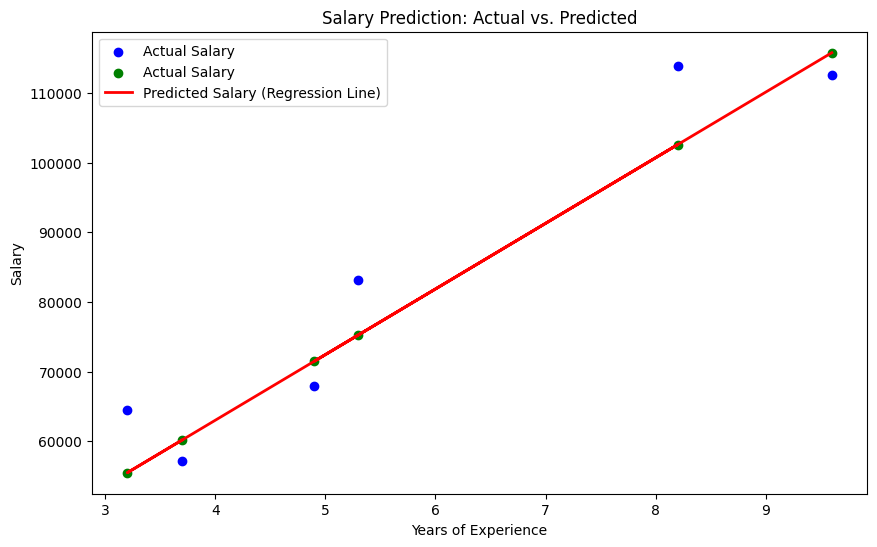

In [10]:
# 6. Visualize the Results
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Salary')
plt.scatter(X_test, y_pred, color='green', label='Actual Salary')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted Salary (Regression Line)') #mse value min vako haru
plt.title('Salary Prediction: Actual vs. Predicted')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

top ko secomd ko ma chai badi error/ diff dekhairako xa

In [11]:
# 7. Make a new prediction
new_experience = np.array([[5]])
predicted_salary = model.predict(new_experience)
print(f"\nPredicted salary for {new_experience[0][0]} years of experience: ${predicted_salary[0]:.2f}")


Predicted salary for 5 years of experience: $72440.66


C:\Users\Asus\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Task
## 200 dataset vako linear regression garera dekhaunee

In [12]:
np.random.seed(42)

years = np.linspace(0.5, 20, 100)
salary = 30000 + (years * 9000) + np.random.normal(0, 8000, 100)

df_generated = pd.DataFrame({
    'YearsExperience': years,
    'Salary': salary.astype(int)
})

print(df_generated.head())

   YearsExperience  Salary
0         0.500000   38473
1         0.696970   35166
2         0.893939   43226
3         1.090909   52002
4         1.287879   39717


random 100 wota dataset thapya

In [14]:
df_generated.shape

(100, 2)

In [15]:
# Additional data points
more_data = {
    'YearsExperience': [
        0.5, 0.8, 1.0,
        11.0, 11.5, 12.0, 12.5,
        13.0, 13.5, 14.0,
        15.0, 16.0, 17.0, 18.0, 19.0, 20.0
    ],
    'Salary': [
        32000, 35000, 38000,
        125000, 130000, 135000, 138000,
        142000, 148000, 150000,
        160000, 170000, 180000, 190000, 200000, 210000
    ]
}

df_more = pd.DataFrame(more_data)

In [18]:
df_more.head()

,YearsExperience,Salary
0,0.5,32000
1,0.8,35000
2,1.0,38000
3,11.0,125000
4,11.5,130000


In [19]:
df_more.shape

(16, 2)

In [17]:
# Combine with original dataset
df_extended = pd.concat([df, df_more, df_generated], ignore_index=True)

print(df_extended.tail())
print("Total records:", len(df_extended))

     YearsExperience  Salary
141        19.212121  191200
142        19.409091  207050
143        19.606061  208542
144        19.803030  208268
145        20.000000  208123
Total records: 146


aba sab dataset add garya

In [20]:
# 3. Prepare Data for Modeling
# X should be a 2D array, so we use [['YearsExperience']]
X = df_extended[['YearsExperience']]
print(X.shape)
y = df_extended['Salary']

(146, 1)


In [21]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


Training set shape: (116, 1)
Testing set shape: (30, 1)


In [24]:
# 4. Choose & Train the Model
model = LinearRegression()
model.fit(X_train, y_train)
print("\nModel training complete.")

# Print the learned parameters
print(f"Coefficient (w1): {model.coef_[0]}")
print(f"Intercept (b): {model.intercept_}")


Model training complete.
Coefficient (w1): 9089.371227091564
Intercept (b): 27966.141155657242


In [23]:
len(X_test)

30

In [25]:
# 5. Evaluate the Model
y_pred = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}") # R2 is the proportion, Closer to 1 is better.

Mean Squared Error (MSE): 53100684.19
Root Mean Squared Error (RMSE): 7287.02
R-squared (R2): 0.98


- mse lai root vitra haleko ho rmse
- accuracy r^2 ho

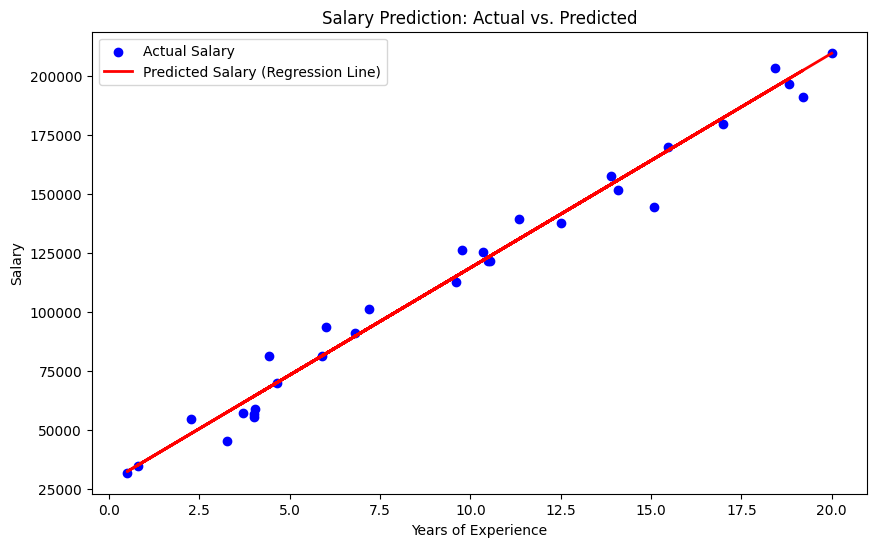

In [27]:
# 6. Visualize the Results
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Salary')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted Salary (Regression Line)')
plt.title('Salary Prediction: Actual vs. Predicted')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

red is nested line vanxa teslai, jasko chai rmse line sabai vanda kam hunxa

In [28]:
# 7. Make a new prediction
new_experience = np.array([[5]])
predicted_salary = model.predict(new_experience)
print(predicted_salary)
print(f"\nPredicted salary for {new_experience[0][0]} years of experience: ${predicted_salary[0]:.2f}")

[73412.99729112]

Predicted salary for 5 years of experience: $73413.00


C:\Users\Asus\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [29]:
import joblib #euta model ho, yesle model le file ma save garxa)
joblib.dump(model, 'salary_linear_regression.pkl')

['salary_linear_regression.pkl']

model banaune extension ho .pkl ra joblib scikit learn ko, hamle tei use garirako xam so, framework anusar farak hunxa

In [30]:
model_file = 'salary_linear_regression.pkl'
model = joblib.load(model_file)
model.predict([[5]])

C:\Users\Asus\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([73412.99729112])

### Model Equation

$$
y = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b
$$

Where:

- $y$ : The predicted value  
- $x_i$ : The input features  
- $w_i$ : The weights (coefficients learned by the model)  
- $b$ : The bias (intercept)

---

## Multiple Linear Regression Example

In this example, we predict **House Price** using multiple features:

- $x_1$ = Size of the house (in square feet)  
- $x_2$ = Number of bedrooms  
- $x_3$ = Age of the house (in years)  

Target:
- $y$ = House price

---

### Model Equation

$$
y = w_1 x_1 + w_2 x_2 + w_3 x_3 + b
$$

Where:

- $y$ : Predicted house price  
- $x_1, x_2, x_3$ : Input features  
- $w_1, w_2, w_3$ : Learned weights (importance of each feature)  
- $b$ : Bias (intercept)

---

### Example With Actual Numbers

Assume the model learned:

$$
w_1 = 120, \quad w_2 = 15000, \quad w_3 = -3000, \quad b = 50000
$$

For a house with:

- Size = 2000 sq ft  
- Bedrooms = 3  
- Age = 10 years  

Prediction:

$$
y = (120 \times 2000) + (15000 \times 3) + (-3000 \times 10) + 50000
$$

$$
y = 240000 + 45000 - 30000 + 50000
$$

$$
y = 305000
$$

So, the predicted house price is:

$$
y = 305000
$$

---

### Vector Form (Compact Representation)

Multiple Linear Regression can also be written as:

$$
y = \mathbf{w}^T \mathbf{x} + b
$$

Where:

$$
\mathbf{w} =
\begin{bmatrix}
w_1 \\
w_2 \\
w_3
\end{bmatrix}
\quad
\mathbf{x} =
\begin{bmatrix}
x_1 \\
x_2 \\
x_3
\end{bmatrix}
$$

In [32]:
# Multiple features dataset
# X1 = Size (sq ft)
# X2 = Bedrooms
# X3 = Age (years)
# y  = House price

X_multi = np.array([
    [2000, 3, 5],
    [1500, 2, 10],
    [2500, 4, 3],
    [1800, 3, 8],
    [2200, 3, 4]
])

y_multi = np.array([300000, 200000, 400000, 280000, 350000])

# Create model
model_multi = LinearRegression()

# Train model
model_multi.fit(X_multi, y_multi)

# Print learned parameters
print("Weights (w1, w2, w3):", model_multi.coef_)
print("Bias (b):", model_multi.intercept_)

# Predict new house price
new_house = [[2100, 3, 6]]
prediction_multi = model_multi.predict(new_house)

print("Prediction for [2100 sq ft, 3 bedrooms, 6 years]:", prediction_multi[0])

Weights (w1, w2, w3): [ 1.75000000e+02  1.25000000e+04 -9.58110701e-12]
Bias (b): -81499.99999999948
Prediction for [2100 sq ft, 3 bedrooms, 6 years]: 323500.0


point paxadi kati hune vanxa, 175, 12500, -0.00000000000958 yesto yesto aauxa

https://www.kaggle.com/datasets/harlfoxem/housesalesprediction?select=kc_house_data.csv